In [107]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv('data.csv')


Lets understand the variables
# Steel Fatigue Dataset: Variable Descriptions

This dataset contains information on steel composition, heat treatment parameters, processing history, microstructure (inclusions), and the resulting fatigue strength. The data originates from the National Institute for Materials Science (NIMS) in Japan.

## Objective: Create a model that mixes chemical composition and heat treatment parameters to model the fatigue strength

##  Chemical Composition (wt%)
| Variable | Description | Materials Engineering Significance |
| :--- | :--- | :--- |
| **C** | % Carbon | The most critical element for strength and hardness. In carburizing steels, base C is low (~0.2%) to keep the core tough, while the surface is enriched to ~0.8% during carburizing. |
| **Si** | % Silicon | Used for deoxidation during steelmaking. Contributes to solid solution strengthening. |
| **Mn** | % Manganese | Improves hardenability and strength. Combines with sulfur to form MnS inclusions. |
| **P** | % Phosphorus | Generally an impurity. Increases strength but severely reduces toughness (temper embrittlement). Kept low in quality steels. |
| **S** | % Sulphur | Generally an impurity. Forms sulfides (MnS) which can be beneficial for machinability but harmful to fatigue life if large or elongated. |
| **Ni** | % Nickel | Improves toughness, hardenability, and corrosion resistance. Retains austenite. |
| **Cr** | % Chromium | Strongly increases hardenability. Forms carbides (Cr carbides), providing wear resistance. Essential in bearing steels. |
| **Cu** | % Copper | Can improve corrosion resistance but may cause hot shortness if present in high amounts. |
| **Mo** | % Molybdenum | Increases hardenability and high-temperature strength. Helps resist temper embrittlement and controls hydrogen attack. |

## Heat Treatment Parameters
| Variable | Description | Materials Engineering Significance |
| :--- | :--- | :--- |
| **NT** | Normalizing Temperature | Heating above the upper critical temperature followed by air cooling. Refines grain structure and homogenizes the microstructure before final machining and heat treatment. |
| **THT** | Through Hardening Temperature | The austenitizing temperature used to harden the steel throughout its section (as opposed to just the surface). |
| **THt** | Through Hardening Time | The holding time at the through-hardening temperature. |
| **THQCr** | Cooling Rate for Through Hardening | How fast the steel is cooled (quenched) to form martensite. Faster rates generally mean higher hardness but more distortion. |
| **CT** | Carburization Temperature | The temperature at which carbon is diffused into the surface. Typically 900-950°C. Higher temperatures increase case depth faster but can cause grain growth. |
| **Ct** | Carburization Time | The duration of the carbon addition stage (the "boost" stage). Longer time = deeper case. |
| **DT** | Diffusion Temperature | Sometimes the temperature is lowered after the boost stage to allow carbon to diffuse inward without adding more at the surface. Often the same as CT. |
| **Dt** | Diffusion time | The time allowed for carbon to diffuse from the surface into the core, smoothing the concentration gradient. |
| **QmT** | Quenching Media Temperature | The temperature of the quenchant (e.g., oil at ~60°C). This affects the cooling rate and thus the final hardness and residual stress state. |
| **TT** | Tempering Temperature | Reheating the quenched steel to a lower temperature (e.g., 150-200°C) to reduce brittleness, relieve residual stresses, and achieve a balance of strength and toughness. |
| **Tt** | Tempering Time | The duration of the tempering process. |
| **TCr** | Cooling Rate for Tempering | How fast the steel is cooled after tempering. For some steels, slow cooling after tempering is necessary to avoid temper embrittlement. |

##  Processing and Microstructure (Inclusions)
| Variable | Description | Materials Engineering Significance |
| :--- | :--- | :--- |
| **RedRatio** | Reduction Ratio (Ingot to Bar) | The amount of mechanical working (forging/rolling) the steel undergoes. Higher ratios mean more break-up of brittle inclusions and a more refined, directional grain structure. |
| **dA** | Area Proportion of Inclusions Deformed by Plastic Work | These are inclusions (like MnS) that elongate in the rolling direction. They can act as stress concentrators, especially in the transverse direction. |
| **dB** | Area Proportion of Inclusions Occurring in Discontinuous Array | Clusters of inclusions. These are particularly dangerous for fatigue as the stress fields around adjacent inclusions can interact. |
| **dC** | Area Proportion of Isolated Inclusions | Single, isolated inclusions (often oxides or silicates). Their size and composition are critical factors in fatigue crack initiation. |

##  Target Property
| Variable | Description | Materials Engineering Significance |
| :--- | :--- | :--- |
| **Fatigue** | Rotating Bending Fatigue Strength at 10⁷ Cycles | The maximum stress a material can withstand for 10 million cycles under rotating bending loads without failing. It is a standard measure of the endurance limit for steels. |



## Lets start with some data analysis

1: Summary statistics


In [108]:
#composition columns
comp_cols = ['C','Si','Mn','P','S','Ni','Cr','Mo','Cu']
for col in comp_cols:
    print(f"{col} min: {df[col].min()}, max: {df[col].max()}")

C min: 0.17, max: 0.63
Si min: 0.16, max: 2.05
Mn min: 0.37, max: 1.6
P min: 0.002, max: 0.031
S min: 0.003, max: 0.03
Ni min: 0.01, max: 2.78
Cr min: 0.01, max: 1.17
Mo min: 0.0, max: 0.24
Cu min: 0.01, max: 0.26


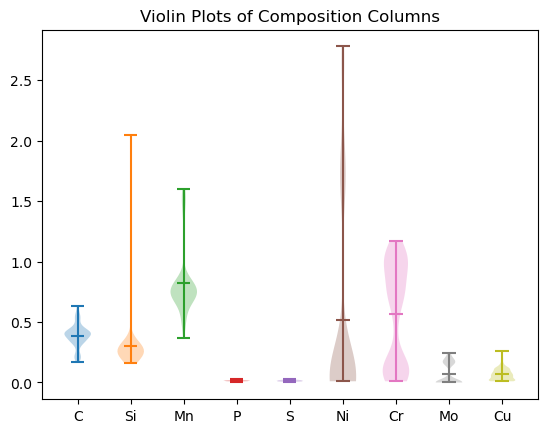

In [109]:

plt.figure()
for col in comp_cols:
    plt.violinplot(df[col], positions=[comp_cols.index(col)], showmeans=True)
plt.xticks(range(len(comp_cols)), comp_cols)
plt.title('Violin Plots of Composition Columns')
plt.show()

Here we can see that the samples composition vary the most in Ni, Si and Mn content, having a weird value of C at 0.6%
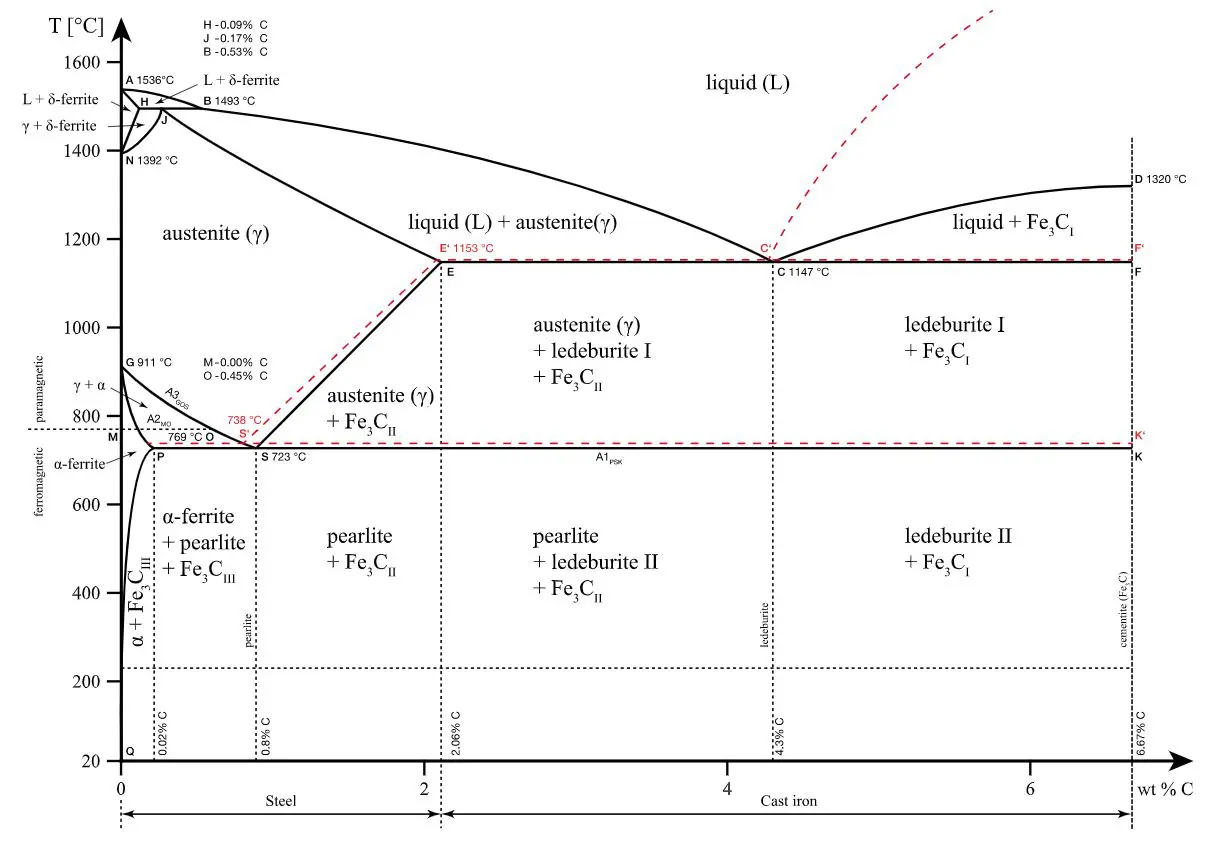
we are then using only the region between 0.17 to 0.6 % carbon

2: Analyze the target variable

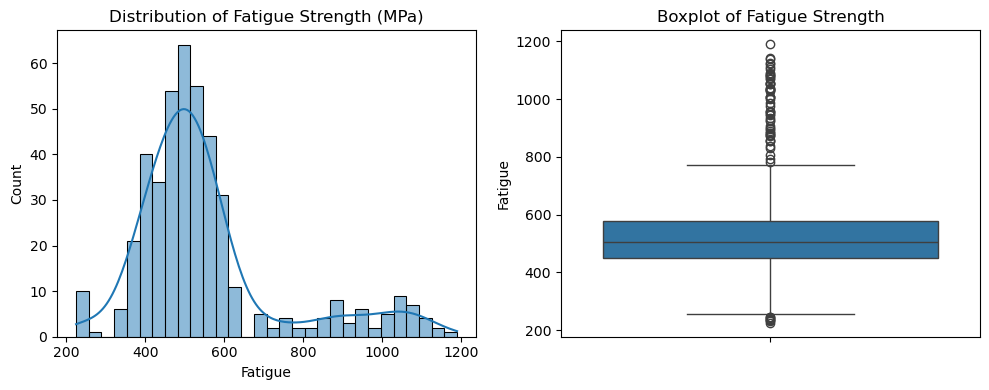

Fatigue - mean: 552.9, std: 186.6
Skewness: 1.56


In [110]:
import seaborn as sns
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
sns.histplot(df['Fatigue'], bins=30, kde=True)
plt.title('Distribution of Fatigue Strength (MPa)')

plt.subplot(1,2,2)
sns.boxplot(y=df['Fatigue'])
plt.title('Boxplot of Fatigue Strength')
plt.tight_layout()
plt.show()

print(f"Fatigue - mean: {df['Fatigue'].mean():.1f}, std: {df['Fatigue'].std():.1f}")
print(f"Skewness: {df['Fatigue'].skew():.2f}")

Here we see two diferent maximums in the distribuition: at around 500 MPa and and 1050 MPa.
It would be a good idea to compare the compositions of both ranges


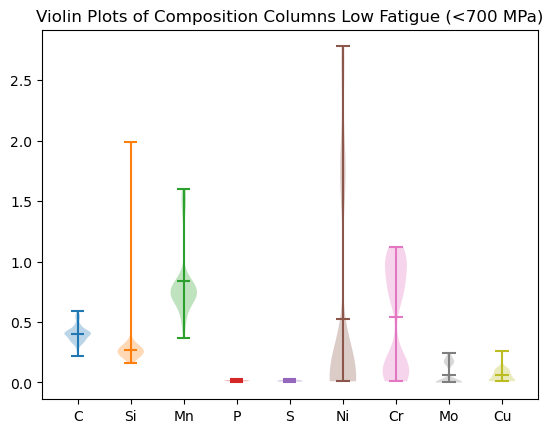

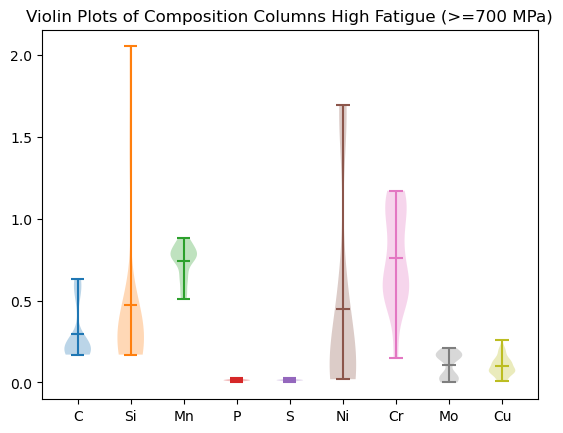

In [111]:
#split the data into fatigue <700 and >=700
df_low = df[df['Fatigue'] < 700]
df_high = df[df['Fatigue'] >= 700]

plt.figure()
for col in comp_cols:
    plt.violinplot(df_low[col], positions=[comp_cols.index(col)], showmeans=True)
plt.xticks(range(len(comp_cols)), comp_cols)
plt.title('Violin Plots of Composition Columns Low Fatigue (<700 MPa)')
plt.show()
plt.figure()
for col in comp_cols:
    plt.violinplot(df_high[col], positions=[comp_cols.index(col)], showmeans=True)
plt.xticks(range(len(comp_cols)), comp_cols)
plt.title('Violin Plots of Composition Columns High Fatigue (>=700 MPa)')
plt.show()

The samples that presented higher fatigue resistance have generally lower carbon higher Cr Ni Mo

In [112]:
# Using IIW formula: CE = C + Mn/6 + (Cr+Mo+V)/5 + (Ni+Cu)/15
if all(col in df.columns for col in ['C','Mn','Cr','Mo','Ni']):
    df['CE_IIW'] = df['C'] + df['Mn']/6 + (df['Cr']+df['Mo'])/5 + df['Ni']/15
    print("CE_IIW added.")

CE_IIW added.


3. Lets dive into the process propeties


In [113]:
process_var=['NT', 'THT', 'THt', 'THQCr', 'CT', 'Ct', 'DT', 'Dt', 'QmT', 'TT', 'Tt', 'TCr']
for col in process_var:
    if col in df.columns:
        print(f"{col} min: {df[col].min()}, max: {df[col].max()}")

NT min: 825, max: 930
THT min: 30, max: 865
THt min: 0, max: 30
THQCr min: 0, max: 24
CT min: 30, max: 930
Ct min: 0.0, max: 540.0
DT min: 30.0, max: 903.333
Dt min: 0.0, max: 70.2
QmT min: 30, max: 140
TT min: 30, max: 680
Tt min: 0, max: 120
TCr min: 0.0, max: 24.0


Here we can see that some samples didnt have certain heat treatments (Through hardening, carburizing, tempering)

So there must be a categorical column to mark that the process was done

In [114]:
df['Through_H'] = df['THt'] != 0
df['Carburized']= df['Ct'] != 0
df['Tempered'] = df['Tt'] != 0

In [115]:
print(f"Through_H - True: {df['Through_H'].sum()}, False: {(~df['Through_H']).sum()}")
print(f"Carburized - True: {df['Carburized'].sum()}, False: {(~df['Carburized']).sum()}")
print(f"Tempered - True: {df['Tempered'].sum()}, False: {(~df['Tempered']).sum()}")

Through_H - True: 378, False: 59
Carburized - True: 48, False: 389
Tempered - True: 426, False: 11


In [116]:
TH = df[(df['Through_H']) & (~df['Carburized']) & (~df['Tempered'])].copy()
C = df[(df['Carburized']) & (~df['Through_H']) & (~df['Tempered'])].copy()
T = df[(df['Tempered']) & (~df['Through_H']) & (~df['Carburized'])].copy()
TH_C = df[(df['Through_H']) & (df['Carburized']) & (~df['Tempered'])].copy()
TH_T = df[(df['Through_H']) & (df['Tempered'])&(~df['Carburized'])].copy()
C_T = df[(df['Carburized']) & (df['Tempered'])&(~df['Through_H'])].copy()
TH_C_T = df[(df['Through_H']) & (df['Carburized']) & (df['Tempered'])].copy()
none = df[(~df['Through_H']) & (~df['Carburized']) & (~df['Tempered'])].copy()

print(f"Through_H & Carburized: {len(TH_C)}")
print(f"Through_H: {len(TH)}")
print(f"Through_H & Tempered: {len(TH_T)}")
print(f"Tempered: {len(T)}")
print(f"Carburized: {len(C)}")
print(f"Carburized & Tempered: {len(CT)}")
print(f"Through_H & Carburized & Tempered: {len(TH_C_T)}")
print(f"None: {len(none)}")



Through_H & Carburized: 0
Through_H: 0
Through_H & Tempered: 378
Tempered: 0
Carburized: 0
Carburized & Tempered: 48
Through_H & Carburized & Tempered: 0
None: 11


## Here we can see that we have two types of samples: 
1. Through hardened and tempered
2. Carburized and Tempered
3. No Heat treatment

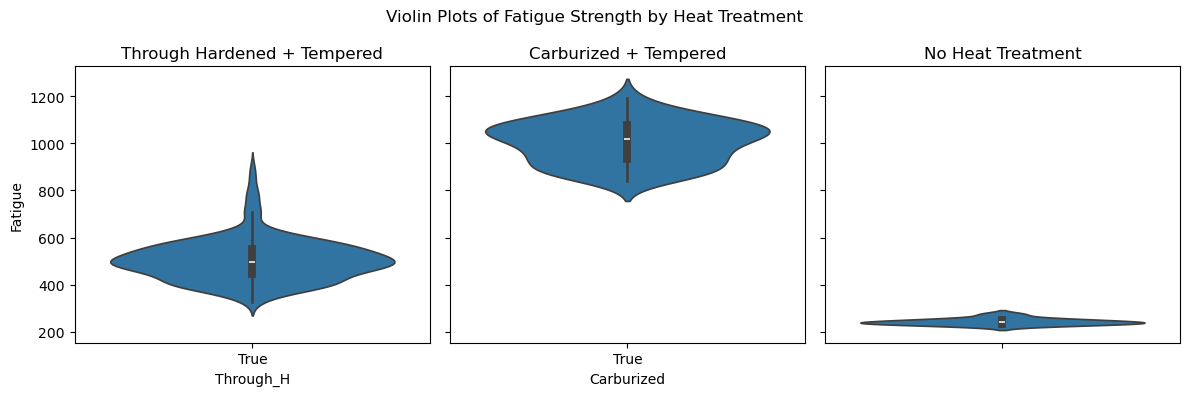

In [117]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

sns.violinplot(ax=axes[0], x='Through_H', y='Fatigue', data=TH_T)
axes[0].set_title('Through Hardened + Tempered')

sns.violinplot(ax=axes[1], x='Carburized', y='Fatigue', data=C_T)
axes[1].set_title('Carburized + Tempered')

sns.violinplot(ax=axes[2], y='Fatigue', data=none)
axes[2].set_title('No Heat Treatment')

fig.suptitle('Violin Plots of Fatigue Strength by Heat Treatment')
plt.tight_layout()
plt.show()


### Here we can see where the distribuition comes from mainly
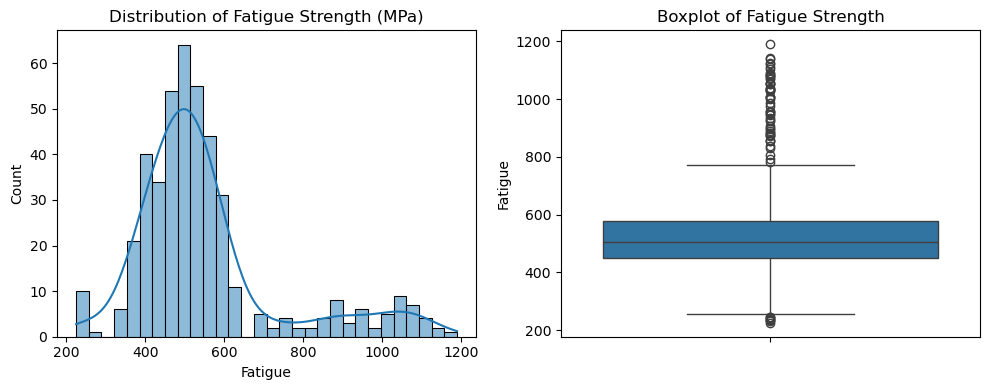

### Evaluate if the tempering parameters are continuous or discrete among the dataset

In [118]:
for col in process_var:
    #print sum of unique values
    print(f"{col} unique values: {TH_T[col].nunique()}, counts: {TH_T[col].value_counts().to_dict()}")


NT unique values: 5, counts: {870: 228, 845: 51, 865: 36, 825: 33, 900: 30}
THT unique values: 4, counts: {845: 198, 855: 111, 865: 36, 825: 33}
THt unique values: 1, counts: {30: 378}
THQCr unique values: 2, counts: {8: 276, 24: 102}
CT unique values: 1, counts: {30: 378}
Ct unique values: 1, counts: {0.0: 378}
DT unique values: 1, counts: {30.0: 378}
Dt unique values: 1, counts: {0.0: 378}
QmT unique values: 1, counts: {30: 378}
TT unique values: 10, counts: {550: 100, 600: 100, 650: 100, 580: 20, 630: 20, 680: 20, 430: 6, 500: 6, 420: 3, 490: 3}
Tt unique values: 1, counts: {60: 378}
TCr unique values: 1, counts: {24.0: 378}


In [119]:
for col in process_var:
    #print sum of unique values
    print(f"{col} unique values: {C_T[col].nunique()}, counts: {C_T[col].value_counts().to_dict()}")


NT unique values: 1, counts: {930: 48}
THT unique values: 1, counts: {30: 48}
THt unique values: 1, counts: {0: 48}
THQCr unique values: 1, counts: {0: 48}
CT unique values: 1, counts: {930: 48}
Ct unique values: 11, counts: {340.2: 9, 469.8: 6, 450.0: 6, 499.8: 6, 139.8: 3, 540.0: 3, 130.2: 3, 510.0: 3, 100.2: 3, 529.8: 3, 90.0: 3}
DT unique values: 6, counts: {895.812: 18, 850.0: 12, 895.517: 9, 882.381: 3, 903.333: 3, 881.807: 3}
Dt unique values: 6, counts: {70.2: 18, 15.0: 12, 34.8: 9, 25.2: 3, 45.0: 3, 49.8: 3}
QmT unique values: 2, counts: {60: 36, 140: 12}
TT unique values: 2, counts: {160: 36, 200: 12}
Tt unique values: 1, counts: {120: 48}
TCr unique values: 1, counts: {0.5: 48}


Here we can clean some variables that will just create noise in th datasets

In [120]:
#print list of features for TH_T and C_T
print("TH_T features:", TH_T.columns.tolist())
print("C_T features:", C_T.columns.tolist())

TH_T features: ['Sl. No.', 'NT', 'THT', 'THt', 'THQCr', 'CT', 'Ct', 'DT', 'Dt', 'QmT', 'TT', 'Tt', 'TCr', 'C', 'Si', 'Mn', 'P', 'S', 'Ni', 'Cr', 'Cu', 'Mo', 'RedRatio', 'dA', 'dB', 'dC', 'Fatigue', 'CE_IIW', 'Through_H', 'Carburized', 'Tempered']
C_T features: ['Sl. No.', 'NT', 'THT', 'THt', 'THQCr', 'CT', 'Ct', 'DT', 'Dt', 'QmT', 'TT', 'Tt', 'TCr', 'C', 'Si', 'Mn', 'P', 'S', 'Ni', 'Cr', 'Cu', 'Mo', 'RedRatio', 'dA', 'dB', 'dC', 'Fatigue', 'CE_IIW', 'Through_H', 'Carburized', 'Tempered']


In [121]:
TH_T_clean=TH_T.drop(['THt','CT','Ct','DT','Dt','QmT','Tt','TCr','Sl. No.','Through_H', 'Carburized', 'Tempered'], axis=1)
C_T_clean=C_T.drop(['NT','THT','THt','THQCr','CT','Tt','TCr','Sl. No.','Through_H', 'Carburized', 'Tempered'], axis=1)


# Model training and testing 

## Ridge Regression, Lasso Regression, Random forest and graident boosting

In [122]:
from sklearn.preprocessing import MinMaxScaler as minmax
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
from sklearn.model_selection import train_test_split
def build_th_models(df):
    """Build and evaluate multiple models for through-hardened data"""
    
    # Separate features and target
    feature_cols = [col for col in df.columns if col != 'Fatigue']
    X = df[feature_cols]
    y = df['Fatigue']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Scale features
    scaler = minmax()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Define models to try
    models = {
        'Ridge Regression': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.01, max_iter=10000),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
    }
    
    results = {}
    
    for name, model in models.items():
        # Train
        model.fit(X_train_scaled, y_train)
        
        # Predict
        y_pred = model.predict(X_test_scaled)
        
        # Metrics
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        results[name] = {
            'MAE': mae,
            'R2': r2,
            'RMSE': rmse,
            'model': model
        }
        
        print(f"\n{name}:")
        print(f"  MAE: {mae:.2f} MPa")
        print(f"  R2:  {r2:.3f}")
        print(f"  RMSE: {rmse:.2f} MPa")
    
    return results, X_train_scaled, y_train, X_test_scaled, y_test, feature_cols

# Run for through-hardened
print("="*50)
print("THROUGH-HARDENED MODEL RESULTS")
print("="*50)
th_results, X_th_train, y_th_train, X_th_test, y_th_test, th_features = build_th_models(TH_T_clean)

THROUGH-HARDENED MODEL RESULTS

Ridge Regression:
  MAE: 19.37 MPa
  R2:  0.926
  RMSE: 26.60 MPa

Lasso:
  MAE: 20.65 MPa
  R2:  0.906
  RMSE: 29.92 MPa

Random Forest:
  MAE: 17.02 MPa
  R2:  0.935
  RMSE: 24.94 MPa

Gradient Boosting:
  MAE: 16.50 MPa
  R2:  0.942
  RMSE: 23.59 MPa


In [123]:
# Run for carburized + tempered
print("="*50)
print("Carburized + Tempered MODEL RESULTS")
print("="*50)
ct_results, X_ct_train, y_ct_train, X_ct_test, y_ct_test, ct_features = build_th_models(C_T_clean)

Carburized + Tempered MODEL RESULTS

Ridge Regression:
  MAE: 30.09 MPa
  R2:  0.863
  RMSE: 32.24 MPa

Lasso:
  MAE: 43.19 MPa
  R2:  0.660
  RMSE: 50.86 MPa

Random Forest:
  MAE: 23.67 MPa
  R2:  0.887
  RMSE: 29.38 MPa

Gradient Boosting:
  MAE: 30.85 MPa
  R2:  0.793
  RMSE: 39.64 MPa


In [124]:

import shap

def analyze_with_shap(model, X_train, feature_names, title):
    """
    Use SHAP values to get both importance and direction.
    SHAP shows how each feature pushes the prediction higher/lower.
    """
    
    # Create SHAP explainer
    if str(type(model)).find('sklearn') > -1:
        # For sklearn models
        explainer = shap.TreeExplainer(model) if hasattr(model, 'feature_importances_') else shap.KernelExplainer(model.predict, X_train[:100])
        
        # Calculate SHAP values (use a sample for speed)
        X_sample = X_train[:100] if len(X_train) > 100 else X_train
        shap_values = explainer.shap_values(X_sample)
        
        # Summary plot
        plt.figure(figsize=(12, 6))
        
        # SHAP summary plot (shows both importance and direction)
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
        plt.title(f'SHAP Values - {title}')
        plt.tight_layout()
        plt.show()
        
        # Bar plot of mean |SHAP| (importance)
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names, 
                          plot_type="bar", show=False)
        plt.title(f'SHAP Feature Importance - {title}')
        plt.tight_layout()
        plt.show()
        
        # Print interpretation guide
        print(f"\n{'='*60}")
        print(f"SHAP INTERPRETATION GUIDE - {title}")
        print(f"{'='*60}")
        print("• SHAP values show how much each feature changes the prediction")
        print("• Positive SHAP = feature pushes prediction HIGHER")
        print("• Negative SHAP = feature pushes prediction LOWER")
        print("• Color shows feature value (red=high, blue=low)")
        print("\nTop features by importance:")
        
        # Calculate mean absolute SHAP values for importance
        mean_shap = np.abs(shap_values).mean(axis=0)
        top_indices = np.argsort(mean_shap)[::-1][:10]
        
        for i, idx in enumerate(top_indices):
            print(f"{i+1}. {feature_names[idx]}: {mean_shap[idx]:.4f}")
        
        return shap_values
    else:
        print(f"SHAP explainer not available for {type(model)}")
        return None

In [125]:
best_carb_model = ct_results['Random Forest']['model']
best_th_model = th_results['Gradient Boosting']['model']

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Enable SHAP plots to show in notebook
shap.initjs()

def complete_shap_analysis(model, X_train, X_test, feature_names, title, dataset_type="regression"):
    """
    Comprehensive SHAP analysis for materials engineering interpretation
    
    Parameters:
    - model: trained model
    - X_train: training features
    - X_test: test features
    - feature_names: list of feature names
    - title: plot title prefix
    - dataset_type: "regression" or "classification"
    """
    
    print(f"\n{'='*80}")
    print(f"SHAP ANALYSIS: {title}")
    print(f"{'='*80}")
    
    # Convert to numpy arrays if needed
    if hasattr(X_train, 'values'):
        X_train_array = X_train.values
    else:
        X_train_array = X_train
        
    if hasattr(X_test, 'values'):
        X_test_array = X_test.values
    else:
        X_test_array = X_test
    
    # Create SHAP explainer based on model type
    if str(type(model)).find('GradientBoosting') > -1 or str(type(model)).find('RandomForest') > -1:
        print("Using TreeExplainer...")
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_array)
        
        # Also get expected value
        expected_value = explainer.expected_value
        if isinstance(expected_value, list):
            expected_value = expected_value[0]  # For multi-class
        
    else:
        print("Using KernelExplainer (slower but works for any model)...")
        # Use a sample of training data for background
        background = X_train_array[np.random.choice(X_train_array.shape[0], 50, replace=False)]
        explainer = shap.KernelExplainer(model.predict, background)
        shap_values = explainer.shap_values(X_test_array[:100])  # Limit for speed
        X_test_array = X_test_array[:100]
    
    # 1. SUMMARY PLOT (Beeswarm) - BEST FOR DIRECTIONAL INSIGHTS
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values, 
        X_test_array, 
        feature_names=feature_names,
        show=False,
        plot_size=(12, 8)
    )
    plt.title(f'SHAP Summary Plot - {title}\n(Red=High Feature Value, Blue=Low Feature Value)', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'shap_summary_{title.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 2. BAR PLOT (Mean |SHAP|) - PURE IMPORTANCE
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values, 
        X_test_array, 
        feature_names=feature_names,
        plot_type="bar",
        show=False,
        plot_size=(10, 6)
    )
    plt.title(f'SHAP Feature Importance - {title}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'shap_importance_{title.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 3. WATERFALL PLOT (for first test sample - shows individual prediction breakdown)
    plt.figure(figsize=(12, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[0], 
            base_values=expected_value,
            data=X_test_array[0],
            feature_names=feature_names
        ),
        show=False,
        max_display=15
    )
    plt.title(f'Waterfall Plot - {title} (First Test Sample)\nBase Value: {expected_value:.1f} MPa', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'shap_waterfall_{title.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 4. DEPENDENCE PLOTS (for top 4 features)
    # Calculate mean absolute SHAP values to find top features
    mean_shap = np.abs(shap_values).mean(axis=0)
    top_feature_indices = np.argsort(mean_shap)[-4:][::-1]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, idx in enumerate(top_feature_indices):
        feature = feature_names[idx]
        
        # SHAP dependence plot
        shap.dependence_plot(
            idx, 
            shap_values, 
            X_test_array,
            feature_names=feature_names,
            ax=axes[i],
            show=False,
            alpha=0.7
        )
        axes[i].set_title(f'SHAP Dependence: {feature}', fontsize=12)
        axes[i].grid(True, alpha=0.3)
    
    plt.suptitle(f'SHAP Dependence Plots - {title}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'shap_dependence_{title.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 5. MATERIALS ENGINEERING INTERPRETATION TABLE
    print(f"\n{'='*60}")
    print(f"MATERIALS ENGINEERING INTERPRETATION - {title}")
    print(f"{'='*60}")
    
    # Create interpretation dataframe
    interpretation = []
    for i, feature in enumerate(feature_names):
        # Calculate average SHAP for this feature
        avg_shap = np.mean(shap_values[:, i])
        abs_shap = mean_shap[i]
        
        # Determine overall direction
        if avg_shap > 0.1:
            direction = "STRONGLY INCREASES"
            symbol = "↑↑"
        elif avg_shap > 0:
            direction = "INCREASES"
            symbol = "↑"
        elif avg_shap > -0.1:
            direction = "SLIGHTLY DECREASES"
            symbol = "↓"
        else:
            direction = "STRONGLY DECREASES"
            symbol = "↓↓"
        
        # Add to interpretation
        interpretation.append({
            'Feature': feature,
            'Importance': abs_shap,
            'Avg_SHAP': avg_shap,
            'Direction': direction,
            'Symbol': symbol
        })
    
    df_interpret = pd.DataFrame(interpretation)
    df_interpret = df_interpret.sort_values('Importance', ascending=False)
    
    # Print in a nice format
    print(f"\n{'Feature':<25} {'Importance':<12} {'Effect Direction':<20} {'Symbol'}")
    print(f"{'-'*70}")
    for idx, row in df_interpret.head(15).iterrows():
        print(f"{row['Feature']:<25} {row['Importance']:<12.4f} {row['Direction']:<20} {row['Symbol']}")
    
    # 6. PROCESS OPTIMIZATION GUIDANCE
    print(f"\n{'='*60}")
    print(f"PROCESS OPTIMIZATION GUIDANCE - {title}")
    print(f"{'='*60}")
    
    print("\n🔧 To INCREASE Fatigue Strength:")
    positive_features = df_interpret[df_interpret['Avg_SHAP'] > 0].head(5)
    for idx, row in positive_features.iterrows():
        print(f"   • Increase {row['Feature']} (importance: {row['Importance']:.3f})")
    
    print("\n⚠️  To AVOID (decreases fatigue strength):")
    negative_features = df_interpret[df_interpret['Avg_SHAP'] < 0].head(5)
    for idx, row in negative_features.iterrows():
        print(f"   • Increase {row['Feature']} (importance: {row['Importance']:.3f})")
    
    return explainer, shap_values, df_interpret


SHAP ANALYSIS: Through-Hardened
Using TreeExplainer...


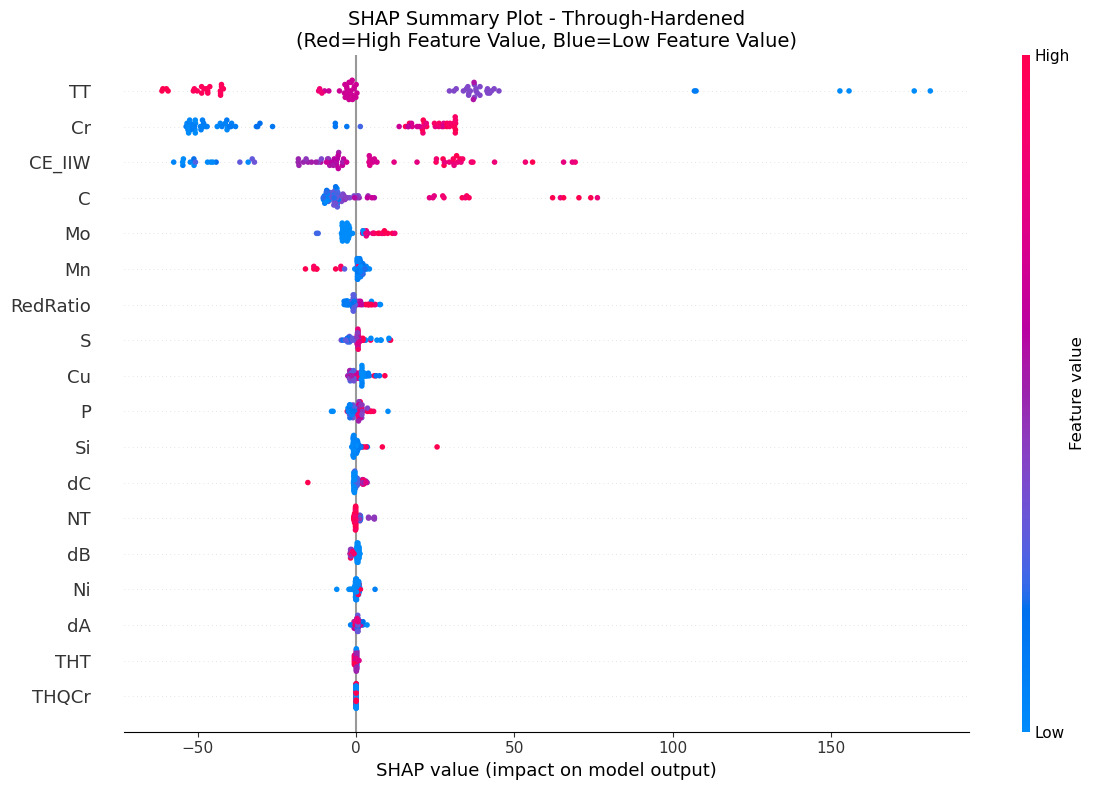

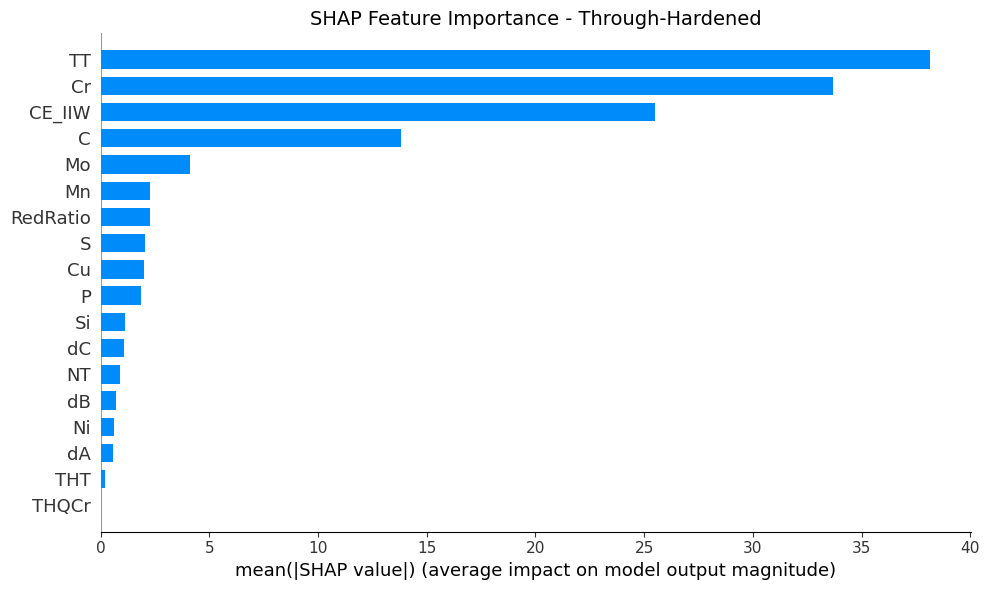

TypeError: unsupported format string passed to numpy.ndarray.__format__

In [127]:
complete_shap_analysis(
    best_th_model, X_th_train, X_th_test, th_features, 'Through-Hardened'
)


SHAP ANALYSIS: Carburized
Using TreeExplainer...


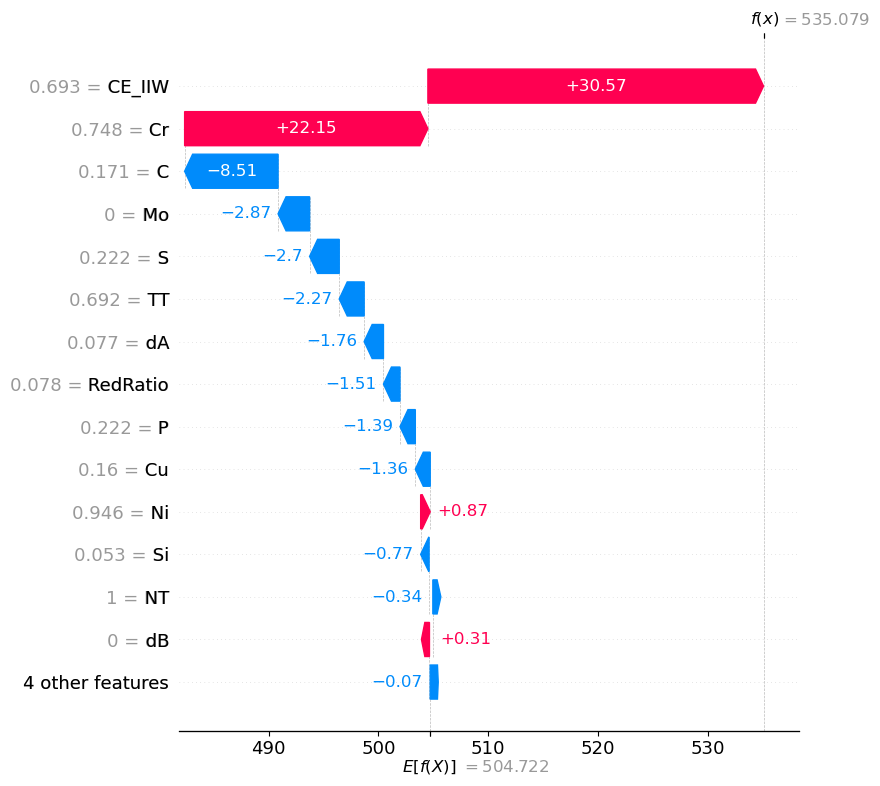

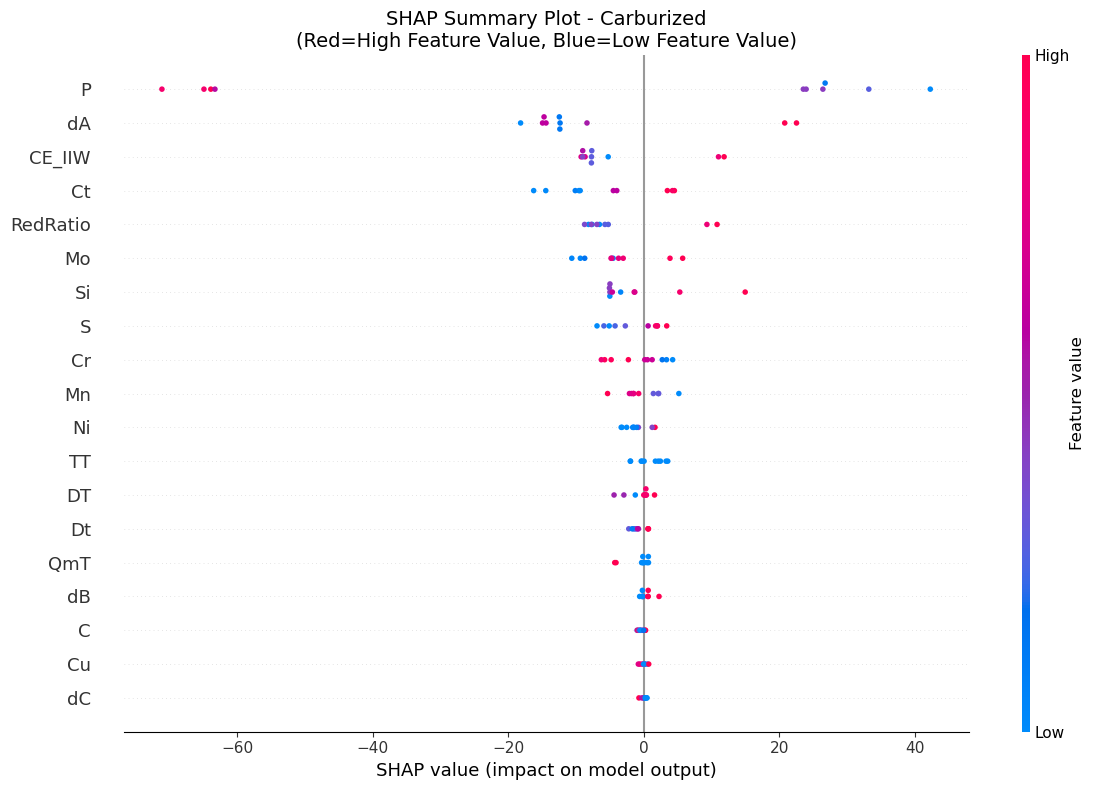

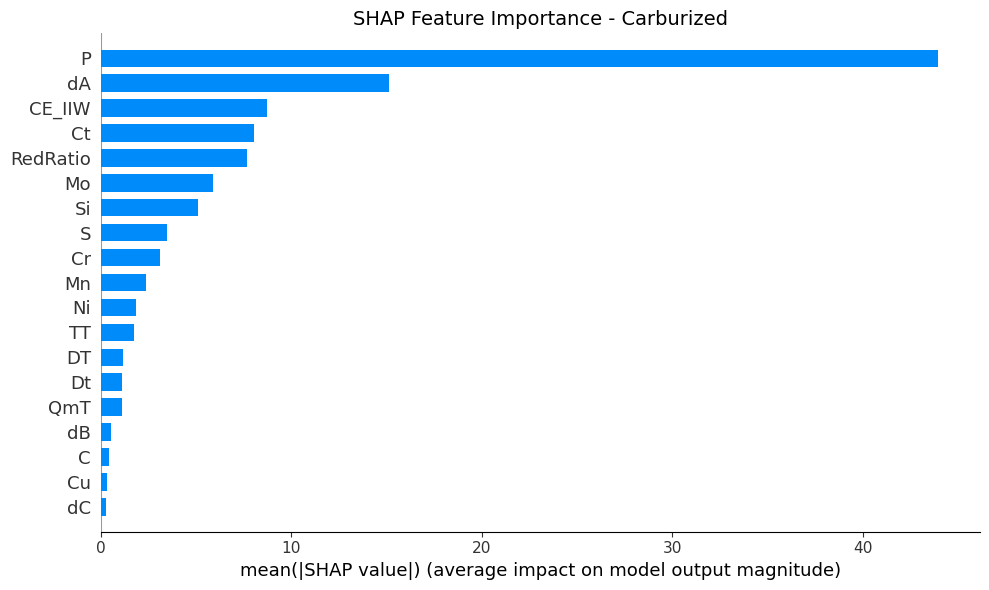

TypeError: unsupported format string passed to numpy.ndarray.__format__

In [ ]:
complete_shap_analysis(
    best_carb_model, X_ct_train, X_ct_test, ct_features, 'Carburized'
)